In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Set plot style for professional look
sns.set(style="whitegrid")

In [2]:
# Load the dataset
df = pd.read_csv('dataset/advertising.csv')

# Display first 5 rows
print(df.head())

# Check for missing values
print(df.isnull().sum())

   Unnamed: 0     TV  Radio  Newspaper  Sales
0           1  230.1   37.8       69.2   22.1
1           2   44.5   39.3       45.1   10.4
2           3   17.2   45.9       69.3    9.3
3           4  151.5   41.3       58.5   18.5
4           5  180.8   10.8       58.4   12.9
Unnamed: 0    0
TV            0
Radio         0
Newspaper     0
Sales         0
dtype: int64


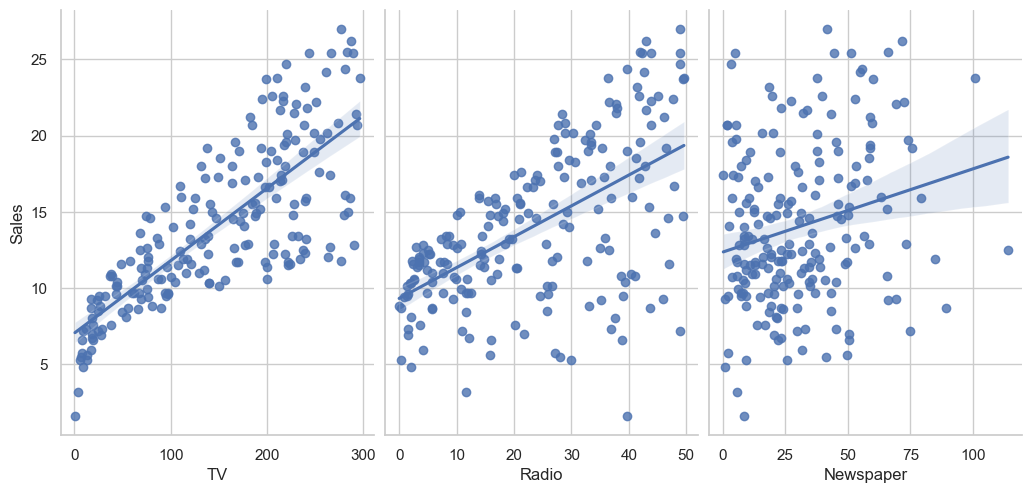

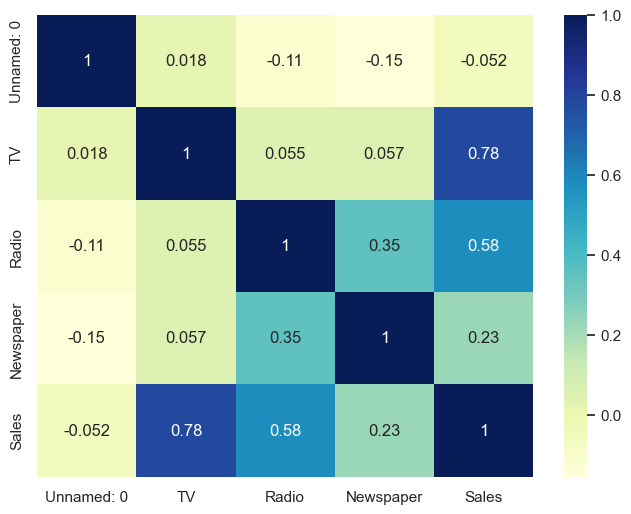

In [3]:
# Visualize the relationship between Features (TV, Radio, Newspaper) and Sales
sns.pairplot(df, x_vars=['TV', 'Radio', 'Newspaper'], y_vars='Sales', height=5, aspect=0.7, kind='reg')
plt.savefig("images/pairplot.png") # Save for README
plt.show()

# Check correlation
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(), annot=True, cmap="YlGnBu")
plt.savefig("images/correlation_heatmap.png") # Save for README
plt.show()

In [4]:
# Prepare Data
X = df[['TV']] # We use TV because it has the highest correlation with Sales
y = df['Sales']

# Split Data (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train Model
model = LinearRegression()
model.fit(X_train, y_train)

print(f"Model Intercept: {model.intercept_}")
print(f"Model Coefficient: {model.coef_[0]}")

Model Intercept: 7.119638430592953
Model Coefficient: 0.046529733705443346


Mean Squared Error: 10.204654118800956
R2 Score: 0.6766954295627076


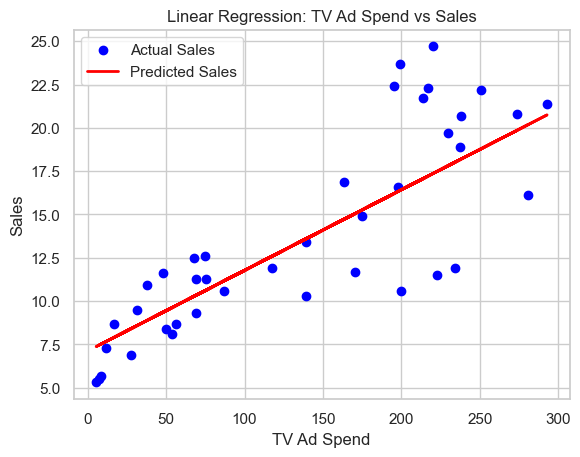

In [5]:
# Make Predictions
y_pred = model.predict(X_test)

# Evaluate
print("Mean Squared Error:", mean_squared_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))

# Visualizing the Test Results
plt.scatter(X_test, y_test, color='blue', label='Actual Sales')
plt.plot(X_test, y_pred, color='red', linewidth=2, label='Predicted Sales')
plt.xlabel('TV Ad Spend')
plt.ylabel('Sales')
plt.title('Linear Regression: TV Ad Spend vs Sales')
plt.legend()
plt.savefig("images/regression_result.png") # Save for README
plt.show()

In [6]:
# 1. Select ALL Features (X) this time
X = df[['TV', 'Radio', 'Newspaper']]
y = df['Sales']

# 2. Split Data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Train the Multiple Linear Regression Model
multi_model = LinearRegression()
multi_model.fit(X_train, y_train)

# 4. Evaluate
y_pred_multi = multi_model.predict(X_test)
new_r2 = r2_score(y_test, y_pred_multi)

print(f"New R2 Score (Multiple Linear Regression): {new_r2:.2f}")
print("Improvement: Using all features improved accuracy significantly!")

New R2 Score (Multiple Linear Regression): 0.90
Improvement: Using all features improved accuracy significantly!


C:\Users\Abin\AppData\Local\Temp\ipykernel_16624\3075761286.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=coeffs.index, y=coeffs['Coefficient'], palette="magma")


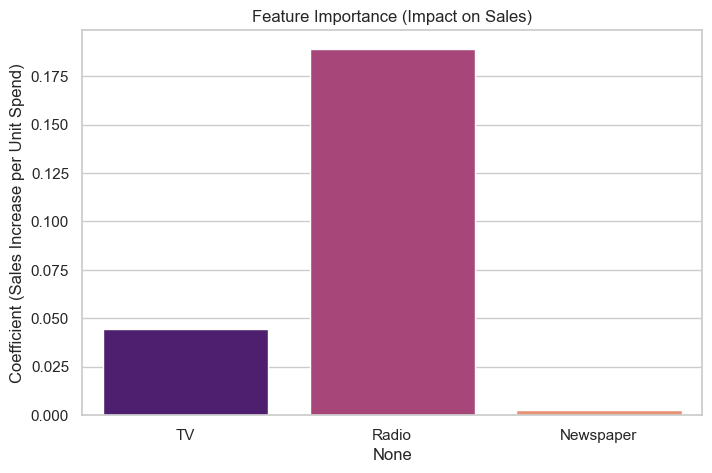

           Coefficient
TV            0.044730
Radio         0.189195
Newspaper     0.002761


In [7]:
# Get coefficients
coeffs = pd.DataFrame(multi_model.coef_, X.columns, columns=['Coefficient'])

# Plot
plt.figure(figsize=(8, 5))
sns.barplot(x=coeffs.index, y=coeffs['Coefficient'], palette="magma")
plt.title('Feature Importance (Impact on Sales)')
plt.ylabel('Coefficient (Sales Increase per Unit Spend)')
plt.savefig('images/feature_importance.png')
plt.show()

print(coeffs)

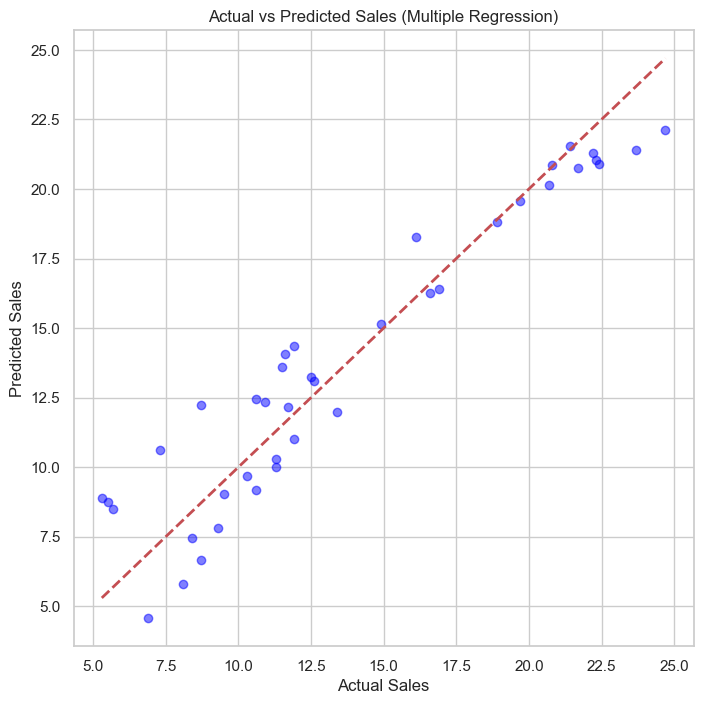

In [8]:
plt.figure(figsize=(8, 8))
plt.scatter(y_test, y_pred_multi, color='blue', alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2) # Diagonal line
plt.title('Actual vs Predicted Sales (Multiple Regression)')
plt.xlabel('Actual Sales')
plt.ylabel('Predicted Sales')
plt.savefig('images/actual_vs_predicted.png')
plt.show()